In [1]:
# Import Basic Packgaes 
import numpy as np
import pandas as pd
from datetime import datetime
import statsmodels as sm
import itertools
import glob
import os
from scipy.signal import argrelextrema
from scipy.signal import find_peaks, peak_widths
import scipy as sp
from sklearn.preprocessing import MinMaxScaler

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns # advanced vizs
from pandas.plotting import lag_plot


# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Set Color Palettes
palette1 = itertools.cycle(sns.color_palette(palette='Set1'))
palette2 = itertools.cycle(sns.color_palette(palette='Set2'))

In [2]:
directory_name = "D:\\2 inch Pump CSV Files\\P1_R12'oclockcrackLgood_CSV File"

In [3]:
os.chdir(directory_name)

In [4]:
os.getcwd()

"D:\\2 inch Pump CSV Files\\P1_R12'oclockcrackLgood_CSV File"

In [5]:
# current directory csv files
csvs = [x for x in os.listdir(directory_name) if x.endswith('.csv')]
# stats.csv -> stats
fns = [os.path.splitext(os.path.basename(x))[0] for x in csvs]

dic_csv = {}
for i in range(len(fns)):
    dic_csv[fns[i]] = pd.read_csv(csvs[i])

In [6]:
dic_csv.keys()

dict_keys(['7_P1_twocrack at bottom left_19&20Oct23'])

In [ ]:
dic_csv['1_P1_R12clockcrackLgood_12Oct23'].info()

In [7]:
clean_dic = {}

In [8]:
for key, df in dic_csv.items():
    clean_dic[key] = df[df['P1-Air-Supply-pressure'] > 90]

In [9]:
for key, df in clean_dic.items():
    df.reset_index(inplace=True, drop=True)

In [ ]:
clean_dic['01_P1_Validation-3_20Oct23'].info()

In [ ]:
for key, df in clean_dic.items():
    df.drop(columns=['P1-CPM','P1-Water Suction Pressure','Time','P1-Water Discharge Pressure','P1-Channel-3','P1-Water Suction Flowrate','P1-Water Discharge Flowrate','P1-Air Supply Flowrate','Cycle-detect'],axis=1, inplace=True)

In [ ]:
for key, df in clean_dic.items():
    df.drop(columns=['Cycle-detect'],axis=1, inplace=True)

In [ ]:
clean_dic['5_P1_R12clockcrackLgood_17Oct23'].info()

In [ ]:
clean_dic['15_P3_LT-II_28Oct23'].drop(columns=['P3-Channel-3'], inplace=True)

In [ ]:
Norm_Dic = {}

In [ ]:
minmax_1c = MinMaxScaler()

In [ ]:
for key, df in clean_dic.items():
    minmax_sf_1c = minmax_1c.fit_transform(df)
    minmax_sf_1c_df = pd.DataFrame(minmax_sf_1c, columns=['minmax_ASP'])
    Norm_Dic[key] = minmax_sf_1c_df


In [10]:
# Get the number of keys in the dictionary
num_keys = len(clean_dic)

# Specify the starting date
start_date = '2023-03-01 00:00:00.000'

# Generate the list of date elements based on the number of keys
Month_date_list = pd.date_range(start_date, freq='1D', periods=num_keys).strftime('%Y-%m-%d %H:%M:%S.%f').tolist()

In [ ]:
Month_date_list 

In [ ]:
Norm_Dic.keys()

In [11]:
for (key, df), i in zip(clean_dic.items(),Month_date_list) :    
    df['newtime'] = pd.date_range(i, freq='30ms', periods=len(df))

In [12]:
for key, df in clean_dic.items():
    df['newtime'] =pd.to_datetime(df['newtime'])

In [13]:
for key, df in clean_dic.items():
    df.set_index(['newtime'], inplace=True)

In [14]:
# Define FFT parameters
dt = 0.03
f1, f2 = 1000, 1000  # Hz
diff = 100

In [ ]:
temp_dic = {}

In [ ]:
for key, df in clean_dic.items():
    # Define the time interval for slicing
    start_time = df.index[0]
    end_time = df.index[-1]
    time_interval = pd.Timedelta(minutes=1)
    
    result_df = pd.DataFrame()
    
    current_time = start_time
    while current_time <= end_time:
        
        next_time = current_time + time_interval
        
        # Slice the DataFrame based on the specified time range
        sliced_df = df.iloc[(df.index >= current_time) & (df.index <= next_time)]
       
        
        # Perform FFT analysis only if there is data in the sliced DataFrame
        n = len(sliced_df)
        if n > 0:
            t = sliced_df.index
            s = sliced_df['P1-Air-Supply-pressure']

            # FFT
            s -= s.mean()
            fr = np.fft.rfftfreq(n, dt)
            fou = np.fft.rfft(s)
            
            # Create a DataFrame for the current fr,amp
            temp_df = pd.DataFrame({'Frequency': fr,'Amplitude': np.abs(fou)})


            # Append the DataFrame to the list
            #freq_amp_dfs.append(temp_df)
            result_df = pd.concat([result_df, temp_df], ignore_index=True)
            
        else:
            # Handle the case where the DataFrame is empty (e.g., print a message)
            print(f"No data in the time range {current_time} - {next_time}")

        current_time = next_time    
    temp_dic[key] = result_df  

In [ ]:
temp_dic.keys()

In [ ]:
output_direct = "D:\\1.5inch Pump Data\\P1_ASP-100,WDP-80\\P1_CSV_Files\\New folder"

In [ ]:
for j, i in temp_dic.items():
    file_name = f"{j}{'fr,amp_1min'}.csv"
    i.to_csv(file_name, index=False)

In [ ]:
for key, df in clean_dic.items():
    # Define the time interval for slicing
    start_time = df.index[0]
    end_time = df.index[-1]
    time_interval = pd.Timedelta(minutes=2)
    
    current_time = start_time
    while current_time <= end_time:
        next_time = current_time + time_interval

        # Slice the DataFrame based on the specified time range
        sliced_df = df.iloc[(df.index >= current_time) & (df.index <= next_time)]

        # Perform FFT analysis only if there is data in the sliced DataFrame
        n = len(sliced_df)
        if n > 0:
            t = sliced_df.index
            s = sliced_df['P1-Air-Supply-pressure']

            # FFT
            s -= s.mean()
            fr = np.fft.rfftfreq(n, dt)
            fou = np.fft.rfft(s)

            # Plot and save the FFT plot
            plt.figure(figsize=(28, 10))
            plt.subplot(211)
            plt.plot(t, s)
            plt.title('Data with Noise')

            plt.subplot(212)
            plt.plot(np.fft.fftshift(fr), np.fft.fftshift(np.abs(fou)))
            plt.xticks(np.arange(min(np.fft.fftshift(fr)), max(np.fft.fftshift(fr)), 0.3))
            plt.ylim(0, 6000)
            plt.title('Spectrum of Noisy Data')

            # Save the plot with a meaningful filename
            filename = os.path.join("D:\\1.5inch Pump Data\\P1_ASP-100,WDP-80\\P1_CSV_Files\\New folder", f'{key}_{current_time.strftime("%H-%M-%S")}_{next_time.strftime("%H-%M-%S")}_FFT.png')
            plt.savefig(filename)
            plt.close()
                #fr_list = [np.fft.fftshift(fr)]
                #amp_list = [np.fft.fftshift(np.abs(fou))]
                #fourier_df = pd.DataFrame(data=[fr_list, amp_list],columns=['frequency','amplidute'])
                #print(fourier_df.loc[fourier_df['amplidute'].idxmax()])

        else:
            # Handle the case where the DataFrame is empty (e.g., print a message)
            print(f"No data in the time range {current_time} - {next_time}")

        current_time = next_time

# Defined Freq data frame

In [15]:
freq_amp_dfs = []

In [16]:
for key, df in clean_dic.items():
    # Define the time interval for slicing
    start_time = df.index[0]
    end_time = df.index[-1]
    time_interval = pd.Timedelta(minutes=2)
    
    result_df = pd.DataFrame()
    
    current_time = start_time
    while current_time <= end_time:
        
        next_time = current_time + time_interval
        
        # Slice the DataFrame based on the specified time range
        sliced_df = df.iloc[(df.index >= current_time) & (df.index <= next_time)]
        
        # Perform FFT analysis only if there is data in the sliced DataFrame
        n = len(sliced_df)
        if n > 0:
            t = sliced_df.index
            s = sliced_df['P1-Air-Supply-pressure']

            # FFT
            s -= s.mean()
            fr = np.fft.rfftfreq(n, dt)
            fou = np.fft.rfft(s)
            
            # Create a DataFrame for the current fr,amp
            temp_df = pd.DataFrame({'Frequency': fr,'Amplitude': np.abs(fou)})


            # Append the DataFrame to the list
            freq_amp_dfs.append(temp_df)
            #result_df = pd.concat([result_df, temp_df], ignore_index=True)
            
        else:
            # Handle the case where the DataFrame is empty (e.g., print a message)
            print(f"No data in the time range {current_time} - {next_time}")

        current_time = next_time    
    #temp_dic[key] = result_df  

In [17]:
sf2_max_list = []

In [ ]:
freq_amp_dfs[0][789:950]

In [18]:
for i in freq_amp_dfs:
   df_Filter =  i[(i['Frequency'] >= 6.506707) & (i['Frequency'] <= 7.806382)]
   sf2_max_list.append(df_Filter.loc[df_Filter['Amplitude'].idxmax()]) 

In [19]:
Sf2_df = pd.DataFrame(sf2_max_list)

In [20]:
Sf2_df.reset_index(inplace=True)

In [21]:
Sf2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   index      230 non-null    int64  
 1   Frequency  230 non-null    float64
 2   Amplitude  230 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 5.5 KB


In [22]:
diaphragm_hr = [n for n in np.arange(0,16,(16/len(Sf2_df)))]

In [23]:
len(diaphragm_hr)

230

In [24]:
Sf2_df['Diaphragm_life'] = diaphragm_hr

In [ ]:
Sf2_df['Diaphragm_life'] = np.round(Sf2_df['Diaphragm_life'], decimals=0).astype(int)

Text(0.5, 1.0, 'Diaphragm lifetime vs Amplitude')

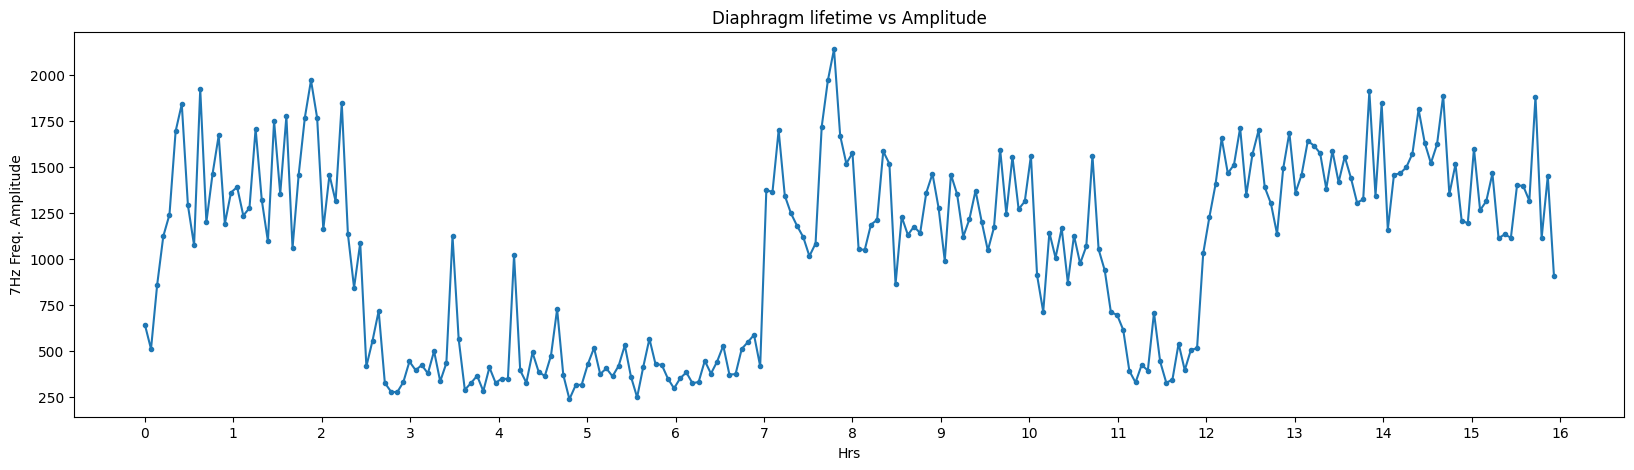

In [25]:
plt.figure(figsize=(20,5))
plt.xticks(np.arange(np.min(Sf2_df.index),np.max(Sf2_df.index),1))
plt.plot(Sf2_df['Diaphragm_life'],Sf2_df['Amplitude'],marker = '.')
plt.xlabel('Hrs')
plt.ylabel('7Hz Freq. Amplitude')
plt.title('Diaphragm lifetime vs Amplitude')

In [ ]:
Sf2_df['Cumulative_Amp'] = Sf2_df['Amplitude'].cumsum()

In [ ]:
Sf2_df.to_csv(r"D:\\P1_2050Hrs_MultipleCracks_Jun.csv")

In [ ]:
# Concatenate all DataFrames in the list into a single DataFrame
#freq_amp_df = pd.concat(freq_amp_dfs, ignore_index=True)

In [ ]:
# Save the result DataFrame to a CSV file
#freq_amp_df.to_csv(r"D:\\2050Hrs FFT and Shannon\\01.P1_100&200_fr,amp.csv")

In [ ]:
# Specify the column you want to extract
column_name = 'Cumulative_Amp'

# Create a new DataFrame to store the specified column from each DataFrame
result_df = pd.DataFrame()

# Loop through each key and DataFrame in dic_csv
for key, df in dic_csv.items():
    # Extract the specified column and add it to the result DataFrame
    result_df[key] = df[column_name]


In [ ]:
len(result_df)

In [ ]:
diaphragm_hr = [n for n in np.arange(0.033179,2050,0.0331790373223708)]

In [ ]:
len(diaphragm_hr)

In [ ]:
result_df['Diaphragm_life'] = diaphragm_hr

In [ ]:
result_df.set_index(['Diaphragm_life'], inplace=True)

In [ ]:
result_df

In [ ]:
result_df.rename({'1.P1_2050Hrs_MultipleCracks_6.5to7.8MaxPoit&Cumsum':'T01_20_2050Hrs_10C',
                  '2.P2_78Hrs_Shaft Failed_6.5to7.8MaxPoit&Cumsum':'T02_20_78Hrs_2C',
                  '3.P3_ADS_failed_6.5to7.8Max Points & Cumsum':'T03_20_370Hrs_0C',
                  '4.P1_300Hrs(1500hrs Aged Diaphragm)_TwoCrack_6.5to7.8Max Points & Cumsum':'T04_20_300Hrs_2C',
                  '5.P1_91Hrs_TwoCrack_6.5to7.8MaxPoit&Cumsum':'T05_20_91Hrs_2C',
                  '6.P3_370Hrs_OneCrack_6.5to7.8MaxPoit&Cumsum':'T06_20_370Hrs_1C',
                  '7.P1_47Hrs_FourCrack_6.5to7.8MaxPoit&Cumsum':'T07_20_47Hrs_4C'},axis=1,inplace=True)


In [ ]:
plt.figure(figsize=(20,10))
#plt.xticks(np.arange(np.min(Merg_df_3Hz['Time']),np.max((Merg_df_3Hz['Time'])),60))
plt.plot(result_df)
#plt.xlim(0,80)
#plt.ylim(0,1500000)
plt.xlabel('Hrs')
plt.ylabel('Sf2_Cumsum_Amp')
plt.title('Diaphragm lifetime vs Amplitude')
plt.legend(result_df, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=5)



In [ ]:
result_df.to_csv(r"D:\\2Inch_Cumsum_amp.csv")

In [ ]:
a = len(dic_csv)  # number of rows
b = 1  # number of columns
c = 1  # initialize plot counter

fig1 = plt.figure(figsize=(25,50))

SMALL_SIZE = 16

for j,i in dic_csv.items():
    plt.subplot(a, b, c)
    #plt.vlines(x=df.index, ymin=0, ymax=df["P3-Cycle-Detect"], linestyles='dashdot',colors='blue')
    #plt.plot(i['Diaphragm_life'], i['Amplitude'])
    plt.plot(i['Diaphragm_life'], i['Cumulative_Amp'])
    #plt.xticks(np.arange(0,len(i),100))
    plt.title(j)
    c = c + 1

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.show()

# Shanon Entropy Calculation

In [ ]:
'''
entropy_list = []
for key, df in clean_dic.items():
    # Define the time interval for slicing
    start_time = df.index[0]
    end_time = df.index[-1]
    time_interval = pd.Timedelta(hours=1)
    
    current_time = start_time
    while current_time <= end_time:
            
        next_time = current_time + time_interval
            
        # Slice the DataFrame based on the specified time range
        sliced_df = df.iloc[(df.index >= current_time) & (df.index <= next_time)]
            
        # Perform FFT analysis only if there is data in the sliced DataFrame
        # Calculate the probabilities
        asp_prob =  sliced_df['P1-Air-Supply-pressure'].value_counts()/sum(sliced_df['P1-Air-Supply-pressure'].value_counts().values)
            
        # Calculate the entropy
        asp_entropy = sp.stats.entropy(asp_prob, base=2)
                
        # Create a DataFrame for the current fr,amp
        #temp_df = pd.DataFrame(asp_entropy,columns=['Entropy'])

        entropy_list.append(asp_entropy)
                
        current_time = next_time

Sh_En = pd.DataFrame(entropy_list,columns=['Entropy'])
# Save the result DataFrame to a CSV file
Sh_En.to_csv(r"D:\\2050Hrs FFT and Shannon\\2050hrs Shannon entorpy\\01.P1_22Oct23_shannon_val.csv")   
'''